In [1]:
# 1. ITEM REFERENCE WEIGHTS (Standardized in Grams)
# Source: Average PET/HDPE manufacturing weights
REFERENCE_WEIGHTS = {
    '50cl_water_bottle': 10.31,  # Standard light-weight PET
    '60cl_soda_bottle': 26.90,   # Heavier PET for carbonated drinks
    '1.5L_water_bottle': 45.00,  # Standard large PET bottle
    'shopping_bag': 5.50,        # Standard HDPE single-use bag
    'pure_water_sachet': 2.50,   # Standard LDPE sachet (empty)
    'generic_plastic_item': 15.0 # Fallback for unlisted items
}

# 2. MATERIAL METRICS (Bulk Density & CO2 Factors)
# Bulk Density (kg/m3) = how much space loose waste takes in a landfill.
# CO2 Factor = kg of CO2 saved per 1kg of plastic recycled.
MATERIAL_METRICS = {
    'PET':  {'bulk_density': 32.0,  'co2_factor': 2.15}, 
    'HDPE': {'bulk_density': 25.0,  'co2_factor': 1.90}, 
    'LDPE': {'bulk_density': 35.0,  'co2_factor': 1.80},
    'OTHER': {'bulk_density': 30.0, 'co2_factor': 1.90}  # Baseline for unclassified plastic 
}

# 3. LANDFILL CONSTANTS
# Typical height of waste stacking in a landfill cell.
STANDARD_LIFT_HEIGHT_M = 2.0

# 4. MARKET PRICES (In Naira or your local currency per KG)
# Note: PET is usually more valuable than mixed plastics/bags.
MARKET_PRICES_PER_KG = {
    'PET': 150.0,   # Example: 150 Naira per kg of PET
    'HDPE': 120.0,  # Example: 120 Naira per kg of HDPE
    'LDPE': 80.0,   # Example: 80 Naira per kg of LDPE (sachets)
    'OTHER': 50.0 # Safe minimum rate for mixed/generic plastic
}

#5 The average grams of plastic per 1cl of liquid volume
BOTTLE_VOLUME_RATIO = 0.35

In [2]:
def get_total_weight_kg(item_type, quantity, vol_cl=None, user_manual_weight=None):
    """
    MASTER WEIGHT LOGIC:
    1. Checks for specific reference items (50cl, 60cl, etc.)
    2. Scales by volume (cl) for unlisted standard bottles
    3. Accepts manual scale readings
    4. Falls back to a generic average
    """
    # PATH A: We have the item in our known dictionary
    if item_type in REFERENCE_WEIGHTS:
        grams = REFERENCE_WEIGHTS[item_type]
        return (grams * quantity) / 1000
    
    # PATH B: It's a standard bottle size not in our list (e.g., a 75cl juice bottle)
    elif vol_cl is not None and vol_cl > 0:
        # BOTTLE_VOLUME_RATIO should be defined in Cell 1 (0.35)
        estimated_grams = vol_cl * BOTTLE_VOLUME_RATIO 
        return (estimated_grams * quantity) / 1000

    # PATH C: The user weighed it themselves on a physical scale
    elif user_manual_weight is not None and user_manual_weight > 0:
        return user_manual_weight 
    
    # PATH D: Absolute fallback (Generic)
    else:
        grams = REFERENCE_WEIGHTS.get('generic_plastic_item', 15.0)
        return (grams * quantity) / 1000
    

def calculate_sdg15_metrics(weight_kg, material_type):
    """
    Calculates Land Saved and Carbon Offset.
    Formula: Land Saved (m2) = (Mass / Bulk Density) / Height
    """
    metrics = MATERIAL_METRICS.get(material_type, MATERIAL_METRICS['OTHER'])
    
    # Calculate volume displaced in cubic meters
    volume_m3 = weight_kg / metrics['bulk_density']
    
    # Calculate land area saved in square meters
    land_saved_m2 = volume_m3 / STANDARD_LIFT_HEIGHT_M
    
    # Calculate CO2 avoided
    co2_saved = weight_kg * metrics['co2_factor']
    
    return round(land_saved_m2, 4), round(co2_saved, 2)



def calculate_payout(weight_kg, material_type):
    """
    Calculates the monetary value of the plastic waste.
    """
    # Look up the price for the specific plastic type
    # If the material_type is unknown, we use the generic_plastic_item_price
    price_per_kg = MARKET_PRICES_PER_KG.get(material_type, MARKET_PRICES_PER_KG['OTHER'])
    
    total_price = weight_kg * price_per_kg
    
    return round(total_price, 2)


In [3]:
def validate_entry(user_reported_kg, recycler_verified_kg):
    """
    Checking if the data is accurate. 
    1. Prevents errors (Zero Check)
    2. Handles pending status
    3. Allows 10% tolerance for human error.
    """
    # 1. Safety check to avoid division by zero error
    if user_reported_kg <= 0:
        return "INVALID", "User reported weight must be greater than zero."

    # 2. Check if the recycler has performed the weighing yet
    if recycler_verified_kg == 0:
        return "PENDING", "Waiting for Recycler verification."
    
    # 3. Calculate the difference percentage
    error_margin = abs(user_reported_kg - recycler_verified_kg) / user_reported_kg
    
    # 4. Final Decision
    if error_margin > 0.10: # 10% Discrepancy limit
        return "FLAG_FOR_REVIEW", f"Error of {error_margin:.1%} exceeds limit."
    
    return "VERIFIED", "Data is accurate."

In [4]:
import pandas as pd

# 1. Create dummy data representing real listings: Representing different user scenarios
# Scenario A: Standard 50cl bottle (Reference)
# Scenario B: A 75cl juice bottle (Volume Scaling)
# Scenario C: A bag of random plastic (Manual Weight)
listings = [
    {
        'Location': 'Ajah',
        'User': 'Amaka', 
        'Item': '50cl_water_bottle', 
        'Qty': 1000, 
        'Vol_cl': None, 
        'Manual_kg': None, 
        'Material': 'PET',
        'Recycler_Actual_kg': 20.62  # Accurate
    },
    {
        'Location': 'Yaba',
        'User': 'Segun', 
        'Item': 'Unlisted_Juice_Bottle', 
        'Qty': 500, 
        'Vol_cl': 75.0, 
        'Manual_kg': None, 
        'Material': 'PET',
        'Recycler_Actual_kg': 13.12  # Accurate
    },
    {
        'Location': 'Ikeja',
        'User': 'Chidi', 
        'Item': 'Mixed_Household_Waste', 
        'Qty': 1, 
        'Vol_cl': None, 
        'Manual_kg': 12.5, 
        'Material': 'OTHER',
        'Recycler_Actual_kg': 5.0     # DISCREPANCY!
    }
]

df = pd.DataFrame(listings)


# 2. Run calculations
df['Calculated_Weight_kg'] = df.apply(
    lambda x: get_total_weight_kg(x['Item'], x['Qty'], x['Vol_cl'], x['Manual_kg']), 
    axis=1
)


# 3. Simulate Recycler Verification (Actual weights found at pickup)
df['Recycler_Actual_kg'] = [10.31, 13.12, 2.5]

# 4. Generate Final Impact Report
def process_verified_impact(row):
    """
    Combines Validation and SDG Impact.
    Impact is ONLY calculated if the Recycler has verified the weight.
    """
    # Step A: Validate the User's claim against the Recycler's scale
    status, note = validate_entry(row['Calculated_Weight_kg'], row['Recycler_Actual_kg'])
    
    # Step B: Only calculate SDG 15 metrics if the status is VERIFIED
    if status == "VERIFIED":
        # We use the Recycler's weight (Source of Truth) for the final science
        land, co2 = calculate_sdg15_metrics(row['Recycler_Actual_kg'], row['Material'])
    else:
        # If it's flagged or pending, we don't count the impact yet
        land, co2 = (0.0, 0.0)
        
    return pd.Series([status, land, co2])

# Apply the function to your dataframe
df[['Status', 'Land_Saved_m2', 'CO2_Saved_kg']] = df.apply(process_verified_impact, axis=1)


# 5. Calculate Price
df['Estimated_Payout_Naira'] = df.apply(
    lambda x: calculate_payout(x['Calculated_Weight_kg'], x['Material']), 
    axis=1
)

 #DISPLAY FINAL RESULTS
print("--- WASTE2BUILD: SDG 15 IMPACT REPORT & ECONOMIC REPORT ---")
display(df[['Location', 'Item', 'Qty', 'Status', 'Estimated_Payout_Naira', 'Land_Saved_m2', 'CO2_Saved_kg']])

--- WASTE2BUILD: SDG 15 IMPACT REPORT & ECONOMIC REPORT ---


,Location,Item,Qty,Status,Estimated_Payout_Naira,Land_Saved_m2,CO2_Saved_kg
0,Ajah,50cl_water_bottle,1000,VERIFIED,1546.50,0.1611,22.17
1,Yaba,Unlisted_Juice_Bottle,500,VERIFIED,1968.75,0.2050,28.21
2,Ikeja,Mixed_Household_Waste,1,FLAG_FOR_REVIEW,625.00,0.0000,0.00


In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. CREATE HISTORICAL DATA (Simulating 500 sellers)
data = {
    'frequency_per_month': np.random.randint(1, 15, 500), # Drop-off counts
    'avg_accuracy_score': np.random.uniform(0.7, 1.0, 500), # 1.0 is perfect
    'total_kg_last_month': np.random.uniform(5, 100, 500),
    'material_purity_rate': np.random.uniform(0.5, 1.0, 500)
}

train_df = pd.DataFrame(data)

# 2. DEFINE THE TARGET: Who is a "Best Seller"?
# Logic: If accuracy > 90% and they bring more than 20kg, they are a 'Best Seller'
train_df['is_best_seller'] = ((train_df['avg_accuracy_score'] > 0.9) & 
                             (train_df['total_kg_last_month'] > 20)).astype(int)


# 3. SPLIT DATA
X = train_df.drop('is_best_seller', axis=1) # Features
y = train_df['is_best_seller'] # Target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


# 4. TRAIN THE MODEL
seller_model = RandomForestClassifier(n_estimators=100)
seller_model.fit(X_train, y_train)


# 5. PREDICTION FUNCTION FOR NEW ONBOARDING (Improved)
def predict_seller_potential(freq, accuracy, total_kg, purity):
    """Predicts if a new onboarding seller has 'Best Seller' potential."""
    
    # Create a small DataFrame so the model sees the feature names it recognizes
    new_seller_df = pd.DataFrame([{
        'frequency_per_month': freq,
        'avg_accuracy_score': accuracy,
        'total_kg_last_month': total_kg,
        'material_purity_rate': purity
    }])
    
    # Now prediction happens without the warning!
    prediction = seller_model.predict(new_seller_df)
    probability = seller_model.predict_proba(new_seller_df)[0][1]
    
    return "High Potential" if prediction[0] == 1 else "Standard", probability

# Example: Checking a new user from Yaba
result, score = predict_seller_potential(10, 0.95, 30, 0.85)
print(f"Onboarding Analysis: {result} (Match Score: {score:.2%})")

Onboarding Analysis: High Potential (Match Score: 81.00%)


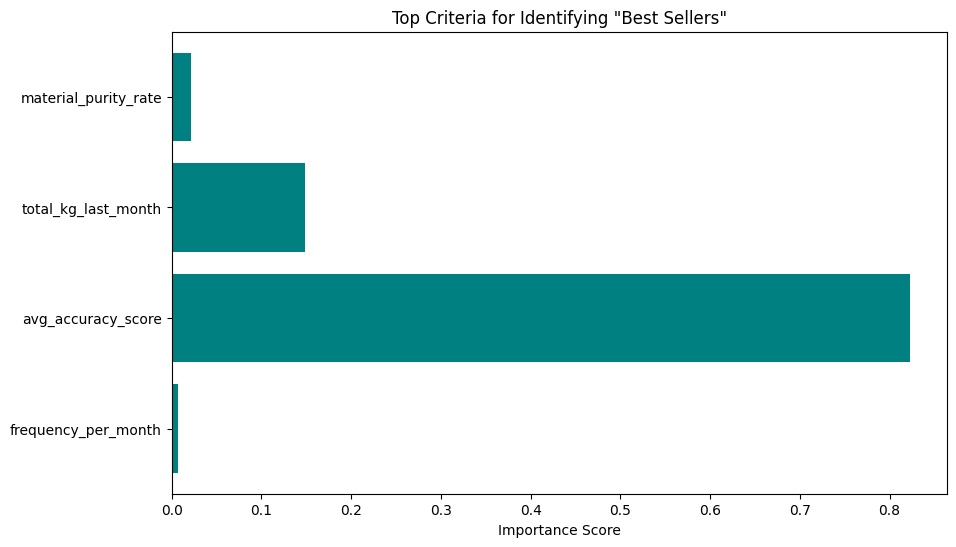

In [6]:
import matplotlib.pyplot as plt

# Get the importance of each characteristic
importances = seller_model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
plt.barh(features, importances, color='teal')
plt.title('Top Criteria for Identifying "Best Sellers"')
plt.xlabel('Importance Score')
plt.show()

In [ ]:
import joblib

# This saves your trained model and the feature names to a file
joblib.dump(seller_model, 'waste2build_model.pkl')

print("Model saved successfully as 'waste2build_model.pkl'!")

Model saved successfully as 'waste2build_model.pkl'!


: 